# Занятие 2. Массивы NumPy.

Булевы массивы и фильтрация массивов. Массив как структура для хранения выборки. Описательные статистики и поиск нехарактерных значений

Преподаватель: Назаровский Егор Борисович

## 1. Зачем NumPy?

NumPy (Numerical Python) — фундаментальная библиотека для научных вычислений в Python.  
Она предоставляет высокоэффективный многомерный массив `ndarray` и набор математических операций над ним.

### Почему не обычные списки Python?

- Python `list` хранит ссылки на объекты произвольного типа → накладные расходы памяти
- Нет нативных векторных операций → нужны циклы
- NumPy хранит элементы одного типа в непрерывном блоке памяти → кэш-дружелюбность
- Операции реализованы на C/Fortran → скорость


In [2]:
import numpy as np
import time

N = 1_000_000

# Python list
py_list = list(range(N))
start = time.perf_counter()
py_result = [x * 2 for x in py_list]
py_time = time.perf_counter() - start

# NumPy array
np_array = np.arange(N)
start = time.perf_counter()
np_result = np_array * 2
np_time = time.perf_counter() - start

print(f"Python list: {py_time:.4f} сек")
print(f"NumPy array: {np_time:.4f} сек")
print(f"Ускорение: ~{py_time / np_time:.0f}x")

Python list: 0.0656 сек
NumPy array: 0.0038 сек
Ускорение: ~17x



## 2. Установка и импорт

```bash
pip install numpy
```

Принятый алиас:
```python
import numpy as np
```


In [3]:
import numpy as np
print(np.__version__)

2.4.4


## 3. `ndarray` — основная структура данных

`numpy.ndarray` — N-мерный массив однородных элементов.

Ключевые свойства:
| Атрибут | Описание |
|---|---|
| `shape` | Кортеж размеров по каждому измерению |
| `dtype` | Тип данных элементов |
| `ndim` | Количество измерений |
| `size` | Общее количество элементов |
| `itemsize` | Размер одного элемента в байтах |
| `nbytes` | Общий объём в байтах |


In [4]:
a = np.array([[1, 2, 3],
              [4, 5, 6]])

print("shape   :", a.shape)
print("dtype   :", a.dtype)
print("ndim    :", a.ndim)
print("size    :", a.size)
print("itemsize:", a.itemsize)
print("nbytes  :", a.nbytes)

shape   : (2, 3)
dtype   : int64
ndim    : 2
size    : 6
itemsize: 8
nbytes  : 48


Массивы могут быть и двумерными, то есть представлять собой таблицу, аналогичную вложенному списку («списку списков»):

In [5]:
np.array([[6, 5],
          [1, 0]])

array([[6, 5],
       [1, 0]])

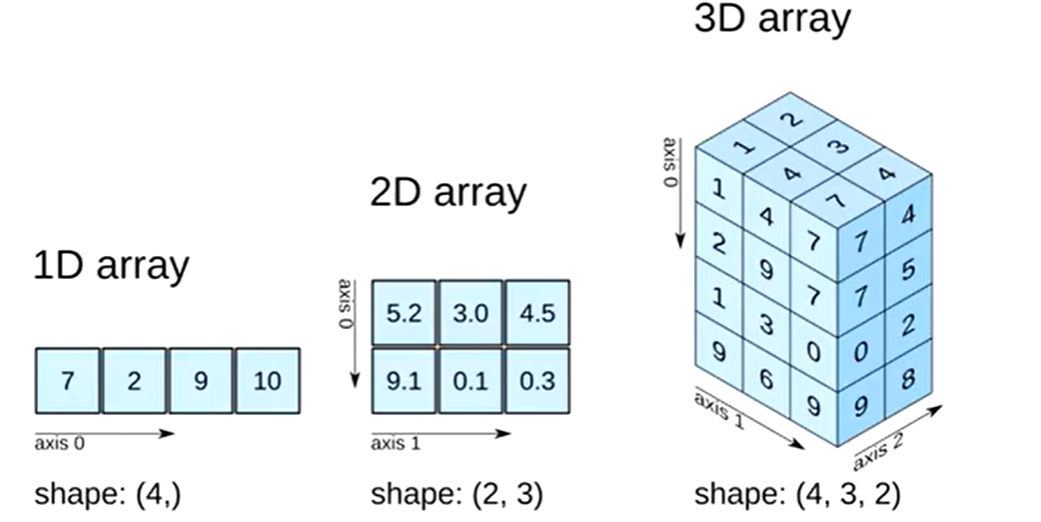

Массивы могут иметь и более высокую размерность — например, «список таблиц» или ещё более сложные структуры (вкладывать списки можно многоуровнево). Однако на практике такие многомерные массивы используются редко.

Зачем изучать массивы?

Во-первых, с ними гораздо удобнее и быстрее работать по сравнению со списками, к тому же они занимают меньше памяти.

Во-вторых, понимание устройства массивов поможет лучше разобраться, как устроены столбцы в датафреймах — тех самых таблицах с данными, с которыми мы будем активно работать дальше.

### Типы данных (dtype)

NumPy поддерживает точные числовые типы — в отличие от Python, где `int` и `float` имеют неограниченную точность.

| dtype | Описание |
|---|---|
| `int8, int16, int32, int64` | Целые числа со знаком |
| `uint8, uint16, uint32, uint64` | Целые без знака |
| `float32, float64` | Числа с плавающей точкой |
| `complex64, complex128` | Комплексные числа |
| `bool` | Булев тип |


In [6]:
# Явное указание dtype

# Приведение типа


## 4. Создание массивов

In [7]:
# Из Python-списков


In [8]:
# Специальные конструкторы


In [9]:
# Диапазоны и последовательности


In [10]:
# Случайные числа


### Задача 1. Создание и атрибуты

Создайте массив из 20 равномерно распределённых значений от 0 до 2π.  
Выведите его `shape`, `dtype` и количество байт.


In [11]:
# Задача 1
x = ???  # np.linspace(...)

print("shape  :", ...)
print("dtype  :", ...)
print("nbytes :", ...)

SyntaxError: invalid syntax (1658821827.py, line 2)

## 5. Индексирование и срезы

Синтаксис срезов: `start:stop:step` — аналогично Python, но расширен на несколько измерений.

> ⚠️ **Важно:** срезы в NumPy возвращают **представление** (view), а не копию!

view - это частный случай shallow copy

In [ ]:
# view vs copy


В NumPy фильтрация происходит через создание булевых масок. Вместо перебора элементов в цикле, мы применяем условие ко всему массиву сразу (векторизация).


In [ ]:
# Булево индексирование


# Fancy indexing (индексирование массивом индексов)


In [ ]:
age =

In [ ]:
mask =

Маска: [ True  True False  True  True False  True  True False]


In [ ]:
# Применение маски для получения значений


Логические операции

Для объединения условий в NumPy используются побитовые операторы:

`& (И)` — оба условия истинны.

`| (ИЛИ)` — хотя бы одно условие истинно.

`~ (НЕ)` — инверсия условия.


Важно: каждое условие должно быть в круглых скобках!

In [ ]:
# Пример: найти тех, кому от 18 до 60 лет включительно
target_group =

### Задача 2. Срезы и булево индексирование

Дана матрица 5×5 из случайных целых чисел от 0 до 100.  
1. Извлеките правый нижний квадрат 3×3.  
2. Замените все элементы, большие 50, на 0 (не создавая копию).


In [ ]:
# Задача 2
rng = np.random.default_rng(seed=0)
m = rng.integers(0, 101, size=(5, 5))
print("Исходная матрица:\n", m)

# 1. Правый нижний квадрат 3×3
sub = ???
print("\nПодматрица 3x3:\n", sub)

# 2. Заменить > 50 на 0
m[???] = 0
print("\nПосле замены:\n", m)

#### Задача 3. Анализ исчезающих языков
У вас есть данные о языках мира.

`speakers` — количество носителей.

`status` — статус (1-5), где 4 — под угрозой, 5 — вымер (0 носителей).


Найдите среднее число носителей для языков, которые: либо имеют статус 4, либо имеют меньше 1000 носителей, но при этом НЕ вымерли (статус != 5)

In [ ]:
# Исходные данные
speakers = np.array([5000, 120, 800, 10, 0, 450, 12000, 300, 0])
status = np.array([1, 4, 2, 4, 5, 3, 1, 4, 5])

mask = (status == 4) | ((speakers < 1000) & (status != 5))
result = np.mean(speakers[mask])

print(f"Результат задачи: {result:.2f}")

Результат задачи: 336.00


---

`np.select` — **условное присваивание нескольких значений.**

Когда условий больше двух, булево индексирование превращается в цепочку присваиваний. `np.select` решает это в одну строку — по аналогии с `switch/case` или серией `if/elif`.

In [ ]:
# Без np.select — громоздко


# С np.select — декларативно


Параметр `default` задаёт значение для элементов, не попавших ни под одно условие. Условия проверяются по порядку — первое совпавшее побеждает, остальные игнорируются.

## 6. Операции над массивами и Broadcasting

Арифметика применяется **поэлементно**. Нет нужды в циклах.

### Broadcasting

Broadcasting — механизм, позволяющий выполнять операции над массивами **разной формы**, не создавая реальных копий данных.

**Правило:** два измерения совместимы, если они равны **или** одно из них равно 1.

```
Shape (3, 1)  +  Shape (1, 4)  →  Shape (3, 4)
```


In [ ]:
col = np.array([[1], [2], [3]])
row = np.array([10, 20, 30, 40])

result = col + row
print(result)
print(result.shape)

In [ ]:
# Практический пример: нормализация признаков (zero-mean)


## 7. Универсальные функции (ufunc)

ufunc — функции, работающие поэлементно с поддержкой broadcasting.


In [ ]:
# Бинарные ufunc

### Задача 4. Broadcasting

Вычислите таблицу евклидовых расстояний между 4 точками на плоскости без явных циклов.  

Подсказка: если `points.shape = (4, 2)`, то  
`diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]` имеет shape `(4, 4, 2)`.


In [ ]:
# Задача 4
points = np.array([[0, 0],
                   [1, 0],
                   [0, 1],
                   [1, 1]], dtype=float)

diff = ???             # broadcasting разности
dist = ???             # np.sqrt(np.sum(diff**2, axis=-1))

print("Матрица расстояний:\n", dist)

### Задача 5. Агрегация и статистика

Сгенерируйте матрицу 100×5, где каждый из 5 столбцов — нормальное распределение  
N(μ, σ²) с разными параметрами (μ = 0,1,2,3,4; σ = 1 для всех).  
Найдите для каждого столбца: среднее, стандартное отклонение, min и max.


In [ ]:
# Задача 5
rng = np.random.default_rng(seed=42)
means = np.arange(5)          # [0, 1, 2, 3, 4]

data = ???                    # shape (100, 5)

print("Mean :", ???)
print("Std  :", ???)
print("Min  :", ???)
print("Max  :", ???)


## 9. Изменение формы массива


In [ ]:
# Транспонирование
np.transpose()

In [12]:
# Объединение и разбиение
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate([a, b]))
print(np.stack([a, b]))
print(np.vstack([a, b]))

parts = np.split(np.arange(9), 3)
print(parts)

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]
[[1 2 3]
 [4 5 6]]
[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8])]


## 10. Линейная алгебра

In [ ]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

# Матричное умножение

# Определитель и обратная матрица

# Собственные значения

#### Задача 7. Работа с матрицами
Дана квадратная матрица 3×3. Выполните следующие операции:

- Вычислите определитель.
- Найдите обратную матрицу.
- Проверьте результат: произведение матрицы на обратную должно давать единичную матрицу. Используйте np.allclose для сравнения.

In [ ]:
A = np.array([[2, 1, 0],
              [1, 3, 1],
              [0, 1, 2]], dtype=float)

# 1. Определитель
det = ???
print(f"det(A) = {det:.2f}")

# 2. Обратная матрица
A_inv = ???
print("A_inv =\n", A_inv)

# 3. Проверка: A @ A_inv должна быть единичной
product = ???
print("A @ A_inv =\n", np.round(product, 10))
print("Равна единичной?", np.allclose(product, ???))



## Итоги лекции

| Тема | Ключевые функции |
|---|---|
| Создание | `array`, `zeros`, `ones`, `arange`, `linspace`, `random.default_rng` |
| Атрибуты | `shape`, `dtype`, `ndim`, `size`, `nbytes` |
| Индексирование | `a[i,j]`, `a[start:stop:step]`, булево, fancy |
| Арифметика | `+`, `-`, `*`, `/`, broadcasting |
| Математика | `sin`, `cos`, `exp`, `log`, `sqrt` |
| Агрегация | `sum`, `mean`, `std`, `min`, `max`, `argmin` |
| Форма | `reshape`, `ravel`, `flatten`, `T`, `concatenate`, `stack` |
| Лин. алгебра | `np.linalg.dot`, `inv`, `det`, `eig`, `solve` |

**На следующем занятии:** введение в Pandas — работа с таблицами и временными рядами.

---
*Полезные ссылки:*
- [NumPy документация](https://numpy.org/doc/stable/)
- [NumPy cheatsheet (DataCamp)](https://www.datacamp.com/cheat-sheet/numpy-cheat-sheet-data-analysis-in-python)
